# Generate Plots of Absolute Geostrophic Velocity in transects of the Beaufort Gyre

### Configure the notebook and load necessary packages

In [8]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod

### Extract the CTD Transects from the full dataset
* Read in the data
* Extract each transect
* Plot the transects on a map

In [10]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BG_LSSL_CTD_2003-2025.nc")

#Slice the data to extract each transect
#Eastern N-S transect (IVO 140˚W)
e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)
#ADD OTHER THREE TRANSECTS

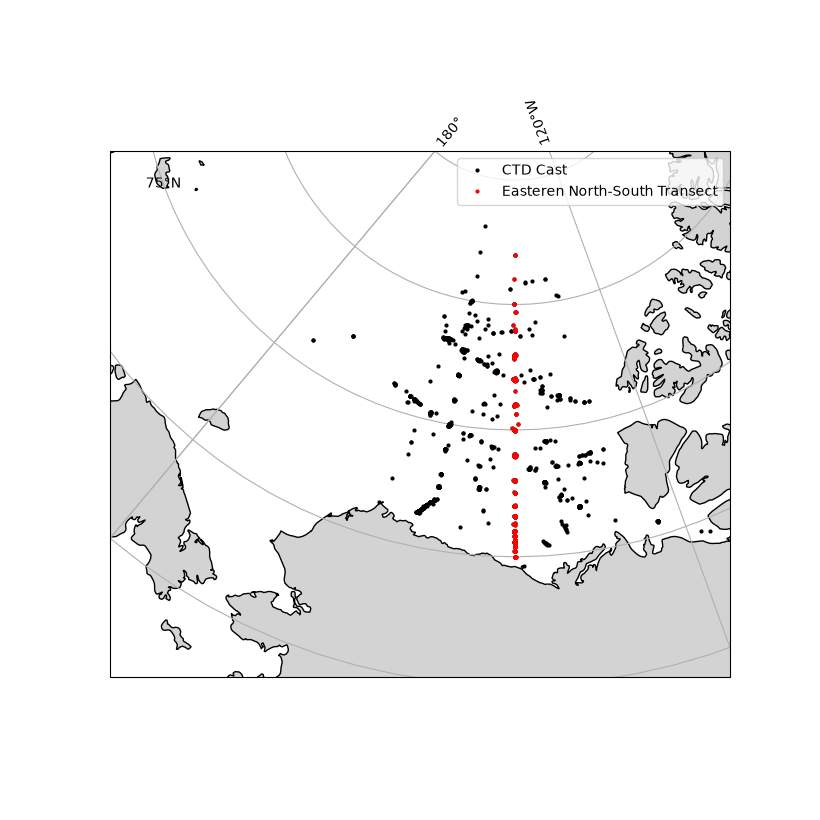

In [11]:
#Plot the transects

#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all casts
ax = mapper.plot_station_locations(ax = ax, ds = ds, label = 'CTD Cast')

#Plat the transects
ax = mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren North-South Transect')

#Finish the plot off
plt.title("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations") #WHY DOESNT THIS WORK?
plt.legend()

plt.show()

### Preprocess the CTD Transects
* Split each transect dataset into an array of data arrays (one for each cruise year)
* Run the injest/cleaning function on each array of transects to remove nan data, calculate various parameters, ensure all variable naming is consistent, and add variable metadata to easier plotting later on
* Includes calculature thermal wind shear ($\frac{\partial \vec{V_g}}{\partial z} = \frac{g}{\rho f_c}(\nabla \times \rho)$)

In [14]:
#Split data into a dataset per cruise 
e_ns_cruise_transects = dsops.split_by_coordinate(e_ns_transect, 'cruise')
#Clean each dataset
for key in e_ns_cruise_transects:
    #Clean and injest the transect data (add many new and useful variables)
    e_ns_cruise_transects[key] = dsops.injest_CTD_transect(e_ns_cruise_transects[key], datum=(70,-140))

### Calculate Absolute Geostrophic Velocity
$\vec{V_g} = \int_{z_0}^{z} \frac{\partial \vec{V_g}}{\partial z} \,dz + \vec{V}_{g, z_0}$
1. Calculate based on a level of no motion of 1000m
2. Calculate based on satelite derived surface geostrophic current


#### Level of no motion at 1000m

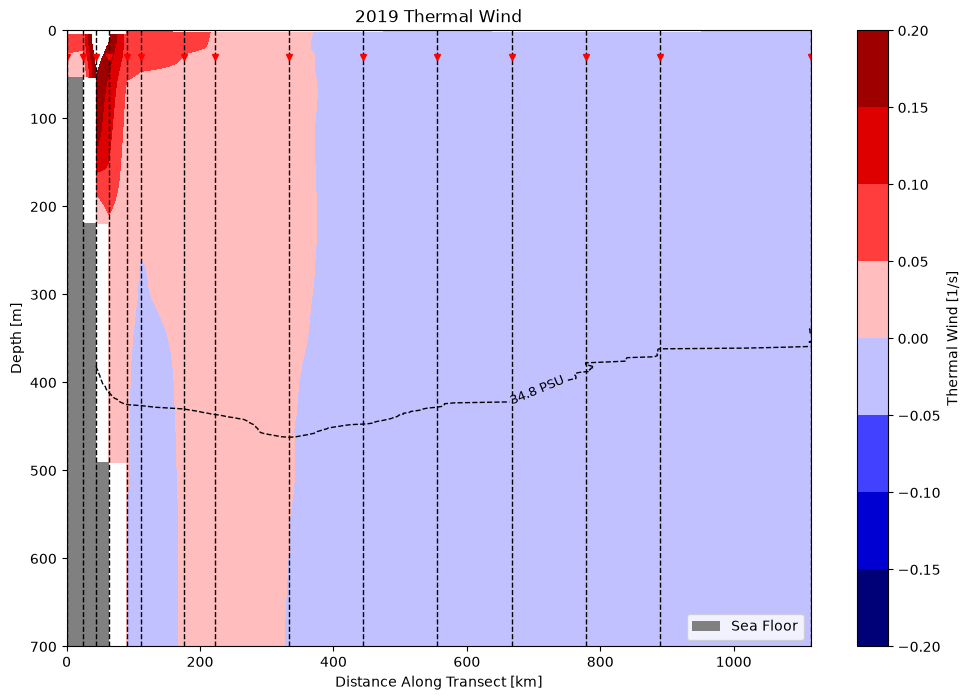

In [131]:
year = 2019
transect = e_ns_cruise_transects[year]
twind_shear = e_ns_cruise_transects[year]['twind']
level_no_motion = 1000

abs_geo_vel = dsops.integrate_level_of_no_motion(twind_shear, level_no_motion)

transect['asv_lom_1000'] = abs_geo_vel


field_figure = plt.figure(figsize=(12,8))
ax = field_figure.add_subplot(1,1,1) 

field_figure, ax = plotter.plot_transect(
    transect=transect,
    x = 'distance',
    y = 'depth',
    data = 'asv_lom_1000',
    fig = field_figure,
    ax = ax,
    cmap = colormaps['seismic'],
    title = f'{year} Thermal Wind',
    levels=[-0.2,0.2]
    )

# plotter.plot_isoline(
#     ax=ax,
#     transect=transect,
#     x_cord_variable='distance',
#     var='psal',
#     value=34.8
# )

plt.show()

In [93]:
transect

<xarray.Dataset> Size: 5MB
Dimensions:       (station: 14, depth: 3840)
Coordinates:
  * station       (station) int64 112B 23 22 21 18 17 16 ... 89 87 85 70 71 72
  * depth         (depth) float64 31kB 0.9896 1.979 ... 3.765e+03 3.766e+03
    prs           (depth) float64 31kB 1.0 2.0 3.0 ... 3.839e+03 3.84e+03
    cruise        int64 8B 2003
Data variables: (12/16)
    psal          (station, depth) float64 430kB nan 31.94 31.92 ... 34.96 34.96
    itmp          (station, depth) float64 430kB nan -0.6717 ... -0.2557 -0.2556
    lat           (station) float64 112B 70.0 70.23 70.4 ... 77.04 77.99 78.95
    lon           (station) float64 112B -140.0 -140.0 -140.0 ... -140.0 -139.9
    date          (station) datetime64[ns] 112B 2003-08-16T08:35:31.999996 .....
    SA            (station, depth) float64 430kB nan 32.09 32.08 ... 35.13 35.13
    ...            ...
    fc            (station) float64 112B 0.000137 0.0001372 ... 0.0001431
    asal          (station, depth) float64 430kB nan 32.09 32.08 ... 35.13 35.13
    ctmp          (station, depth) float64 430kB nan -0.6616 ... -0.5092 -0.5092
    distance      (station) float64 112B 0.4481 25.54 44.62 ... 888.9 995.4
    twind         (station, depth) float64 430kB nan -0.03419 ... nan nan
    asv_lom_1000  (station, depth) float64 430kB nan 0.3239 0.2926 ... nan nan